# Task 6: Policy Evaluation

This notebook first creates the historical input-data CSV, then evaluates the selected policies, creates tables, plots the results, and saves the outputs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from Task6_Environment import run_policy, dummy_action

## 1. Set Up Data File Paths

The environment reads prices and occupancies directly from the three source CSV files ? no intermediate CSV is created.

In [2]:
# Paths to the three source CSV files (same directory as this notebook)
price_csv = Path("v2_PriceData.csv")
occ1_csv  = Path("OccupancyRoom1.csv")
occ2_csv  = Path("OccupancyRoom2.csv")

# Output directory for saved figures
INPUT_OUTPUT_DIR = Path("output")
INPUT_OUTPUT_DIR.mkdir(exist_ok=True)

# Quick sanity check
for p in [price_csv, occ1_csv, occ2_csv]:
    n_rows = len(pd.read_csv(p))
    print(f"?  {p.name}  ?  {n_rows} days")

?  v2_PriceData.csv  ?  100 days
?  OccupancyRoom1.csv  ?  100 days
?  OccupancyRoom2.csv  ?  100 days


In [3]:
# ── Highlight day — used in every state-evolution plot below ──────────────────
# Pick a day with a wide price spread so policy differences show up clearly.
# Day 7 (index 6): prices 3.37 – 12.00 €/kWh  (max price in the dataset).
HIGHLIGHT_DAY = 6   # 0-indexed; change here to update all plots simultaneously

# Pre-load CSV matrices so collect_traj() and the hindsight extractor
# can build trajectories without re-reading files each time.
_prc_df     = pd.read_csv(price_csv)
_oc1_df     = pd.read_csv(occ1_csv)
_oc2_df     = pd.read_csv(occ2_csv)
PRICES_MAT  = _prc_df[[str(i) for i in range(1, 11)]].values   # (N_DAYS, 10)
PREV_PR_MAT = _prc_df.iloc[:, 0].values                        # (N_DAYS,)
OCC1_MAT    = _oc1_df[[str(i) for i in range(10)]].values      # (N_DAYS, 10)
OCC2_MAT    = _oc2_df[[str(i) for i in range(10)]].values      # (N_DAYS, 10)
N_DAYS_PLOT = len(PRICES_MAT)

# Physical thresholds (used for threshold lines in plots)
from v2_SystemCharacteristics import get_fixed_data as _gfd
_sys_data = _gfd()
T_LOW_V  = _sys_data['temp_min_comfort_threshold']   # 18 °C
T_HIGH_V = _sys_data['temp_max_comfort_threshold']   # 26 °C
H_HIGH_V = _sys_data['humidity_threshold']

print(f"HIGHLIGHT_DAY = {HIGHLIGHT_DAY + 1} (1-indexed)")
print(f"  price range on that day: "
      f"{PRICES_MAT[HIGHLIGHT_DAY].min():.2f} – {PRICES_MAT[HIGHLIGHT_DAY].max():.2f} €/kWh")
print(f"Thresholds → T_low={T_LOW_V}°C  T_high={T_HIGH_V}°C  H_high={H_HIGH_V}%")

HIGHLIGHT_DAY = 7 (1-indexed)
  price range on that day: 3.37 – 12.00 €/kWh
Thresholds → T_low=18.0°C  T_high=26.0°C  H_high=70.0%


In [4]:
from Task6_Environment import apply_dynamics, check_feasibility

# ── Trajectory collector ───────────────────────────────────────────────────────
def collect_traj(policy_fn):
    """
    Simulate policy_fn on all N_DAYS_PLOT CSV days.
    Records the state BEFORE each action and the action chosen.
    Returns dict of arrays shaped (N_DAYS_PLOT, 10).
    """
    T1_a = np.zeros((N_DAYS_PLOT, 10)); T2_a = np.zeros((N_DAYS_PLOT, 10))
    H_a  = np.zeros((N_DAYS_PLOT, 10)); c_a  = np.zeros((N_DAYS_PLOT, 10), dtype=int)
    p1_a = np.zeros((N_DAYS_PLOT, 10)); p2_a = np.zeros((N_DAYS_PLOT, 10))
    v_a  = np.zeros((N_DAYS_PLOT, 10), dtype=int)
    pr_a = np.zeros((N_DAYS_PLOT, 10))

    for di in range(N_DAYS_PLOT):
        prices = PRICES_MAT[di]; o1s = OCC1_MAT[di]; o2s = OCC2_MAT[di]
        state  = {
            'T1': 21.0, 'T2': 21.0, 'H': 40.0, 'c': 0,
            'y_low_1': 0, 'y_low_2': 0, 'y_high_1': 0, 'y_high_2': 0,
            'current_time': 0,
        }
        for t in range(10):
            state['price']          = float(prices[t])
            state['price_previous'] = float(prices[t-1]) if t > 0 else float(PREV_PR_MAT[di])
            state['occ1']           = float(o1s[t])
            state['occ2']           = float(o2s[t])
            state['current_time']   = t

            # Record state BEFORE action (what the policy observes)
            T1_a[di, t] = state['T1'];  T2_a[di, t] = state['T2']
            H_a[di, t]  = state['H'];   c_a[di, t]  = state['c']
            pr_a[di, t] = float(prices[t])

            # Get action with safety fallback
            try:
                dec = policy_fn(state)
            except Exception:
                dec = dummy_action(state)
            if not check_feasibility(dec):
                dec = dummy_action(state)

            p1_a[di, t] = float(dec.get('HeatPowerRoom1', 0.0))
            p2_a[di, t] = float(dec.get('HeatPowerRoom2', 0.0))
            v_a[di, t]  = int(float(dec.get('VentilationON', 0)) > 0.5)

            state, _ = apply_dynamics(state, dec)

    return {'T1': T1_a, 'T2': T2_a, 'H': H_a, 'c': c_a,
            'p1': p1_a, 'p2': p2_a, 'v': v_a, 'price': pr_a}


# ── State-evolution plot ───────────────────────────────────────────────────────
def plot_state_evolution(traj, policy_name, day=None):
    """
    2×3 grid of state & action trajectories over the 10-hour day.
    Light grey  = all N_DAYS_PLOT days.
    Solid colour = the chosen highlight day.
    Ventilation ON hours are shaded on the Price panel.
    """
    if day is None:
        day = HIGHLIGHT_DAY
    HOURS = np.arange(10)
    _GREY = '#cccccc'
    _HL   = ['#d62728', '#9467bd', '#1f77b4', '#ff7f0e', '#2ca02c', '#e377c2']

    panels = [
        ('T1',    'Temperature Room 1', '°C',
         [(T_LOW_V,  '#d62728', f'T_low = {T_LOW_V} °C'),
          (T_HIGH_V, '#2ca02c', f'T_high = {T_HIGH_V} °C')]),
        ('T2',    'Temperature Room 2', '°C',
         [(T_LOW_V,  '#d62728', ''),
          (T_HIGH_V, '#2ca02c', '')]),
        ('H',     'Humidity',           '%',
         [(H_HIGH_V, '#1f77b4', f'H_high = {H_HIGH_V} %')]),
        ('p1',    'Heating Power R1',   'kW',   []),
        ('p2',    'Heating Power R2',   'kW',   []),
        ('price', 'Electricity Price',  '€/kWh', []),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
    fig.suptitle(
        f'{policy_name}  —  State & Action Evolution\n'
        f'Light grey: all {N_DAYS_PLOT} days  |  '
        f'Colour: Day {day + 1}  '
        f'(price {traj["price"][day].min():.2f} – {traj["price"][day].max():.2f} €/kWh)',
        fontsize=11, fontweight='bold',
    )

    for idx, (ax, (key, title, ylabel, thresholds)) in enumerate(
            zip(axes.flat, panels)):

        # Grey lines — all days except highlighted
        for d in range(N_DAYS_PLOT):
            if d != day:
                ax.plot(HOURS, traj[key][d],
                        color=_GREY, lw=0.7, alpha=0.45, zorder=1)

        # Highlighted day
        ax.plot(HOURS, traj[key][day],
                color=_HL[idx], lw=2.5, zorder=3,
                marker='o', ms=4.5, label=f'Day {day + 1}')

        # Comfort / operational threshold lines
        for val, col, lbl in thresholds:
            ax.axhline(val, color=col, ls='--', lw=1.2, alpha=0.8,
                       label=lbl if lbl else None)

        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xticks(HOURS)
        ax.set_xticklabels([f'h{h}' for h in HOURS], fontsize=8)
        if idx >= 3:
            ax.set_xlabel('Hour', fontsize=9)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.25, ls='--')

    # Shade ventilation-ON hours on the Price panel
    ax_pr = axes[1, 2]
    for d in range(N_DAYS_PLOT):
        if d != day:
            for t in range(10):
                if traj['v'][d, t]:
                    ax_pr.axvspan(t - 0.45, t + 0.45,
                                  color=_GREY, alpha=0.08, zorder=0)
    _vent_labelled = False
    for t in range(10):
        if traj['v'][day, t]:
            ax_pr.axvspan(t - 0.45, t + 0.45,
                          color='#aec7e8', alpha=0.55, zorder=2,
                          label='Vent ON' if not _vent_labelled else None)
            _vent_labelled = True
    # Re-deduplicate legend on price panel
    _h, _l = ax_pr.get_legend_handles_labels()
    ax_pr.legend(dict(zip(_l, _h)).values(), dict(zip(_l, _h)).keys(),
                 fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.show()


print("collect_traj() and plot_state_evolution() ready.")

collect_traj() and plot_state_evolution() ready.


---
## 2. Hindsight-Optimal Lower Bound

Solves the **10-step perfect-information MILP** for every day in the same CSV created in Step 1.  
All future prices and occupancies are passed to the solver simultaneously â€” this is the **best possible outcome** any causal policy could ever achieve.

The hindsight-optimal cost is a **provable lower bound**: no policy that observes information sequentially can beat it.

Implementation: `hindsight_optimization.py` (Task 1 formulation from the assignment PDF).

Set `VERBOSE = True` to print the optimal cost for each individual day.

In [5]:
import importlib, hindsight_optimization as _ho_mod
importlib.reload(_ho_mod)                  # always reload from disk (picks up any edits)
from hindsight_optimization import run_hindsight

VERBOSE  = True
NUM_DAYS = 100
print(f"Running hindsight-optimal MILP on {NUM_DAYS} days\n")

hindsight_costs, hindsight_details = run_hindsight(
    price_csv, occ1_csv, occ2_csv, verbose=VERBOSE
)

valid = hindsight_costs[~np.isnan(hindsight_costs)]
print(f"\nHindsight-Optimal Results ({len(valid)}/{NUM_DAYS} days feasible):")
print(f"  Mean daily cost : {valid.mean():.3f} euro")
print(f"  Std             : {valid.std():.3f} euro")
print(f"  Min             : {valid.min():.3f} euro")
print(f"  Max             : {valid.max():.3f} euro")

Running hindsight-optimal MILP on 100 days

  Day   1/100  |  optimal cost =   96.20 euro  |  prices  [3.03, 7.05]
  Day   2/100  |  optimal cost =  137.71 euro  |  prices  [3.30, 8.65]
  Day   3/100  |  optimal cost =  181.01 euro  |  prices  [4.22, 8.30]
  Day   4/100  |  optimal cost =  108.29 euro  |  prices  [3.30, 5.28]
  Day   5/100  |  optimal cost =  153.05 euro  |  prices  [2.93, 7.22]
  Day   6/100  |  optimal cost =   43.18 euro  |  prices  [0.66, 6.05]
  Day   7/100  |  optimal cost =  207.88 euro  |  prices  [3.37, 12.00]
  Day   8/100  |  optimal cost =  189.14 euro  |  prices  [5.58, 9.64]
  Day   9/100  |  optimal cost =   99.15 euro  |  prices  [1.68, 6.49]
  Day  10/100  |  optimal cost =  142.83 euro  |  prices  [2.72, 7.02]
  Day  11/100  |  optimal cost =   10.98 euro  |  prices  [0.04, 2.40]
  Day  12/100  |  optimal cost =  146.02 euro  |  prices  [0.97, 10.08]
  Day  13/100  |  optimal cost =  180.19 euro  |  prices  [2.18, 10.19]
  Day  14/100  |  optimal cost

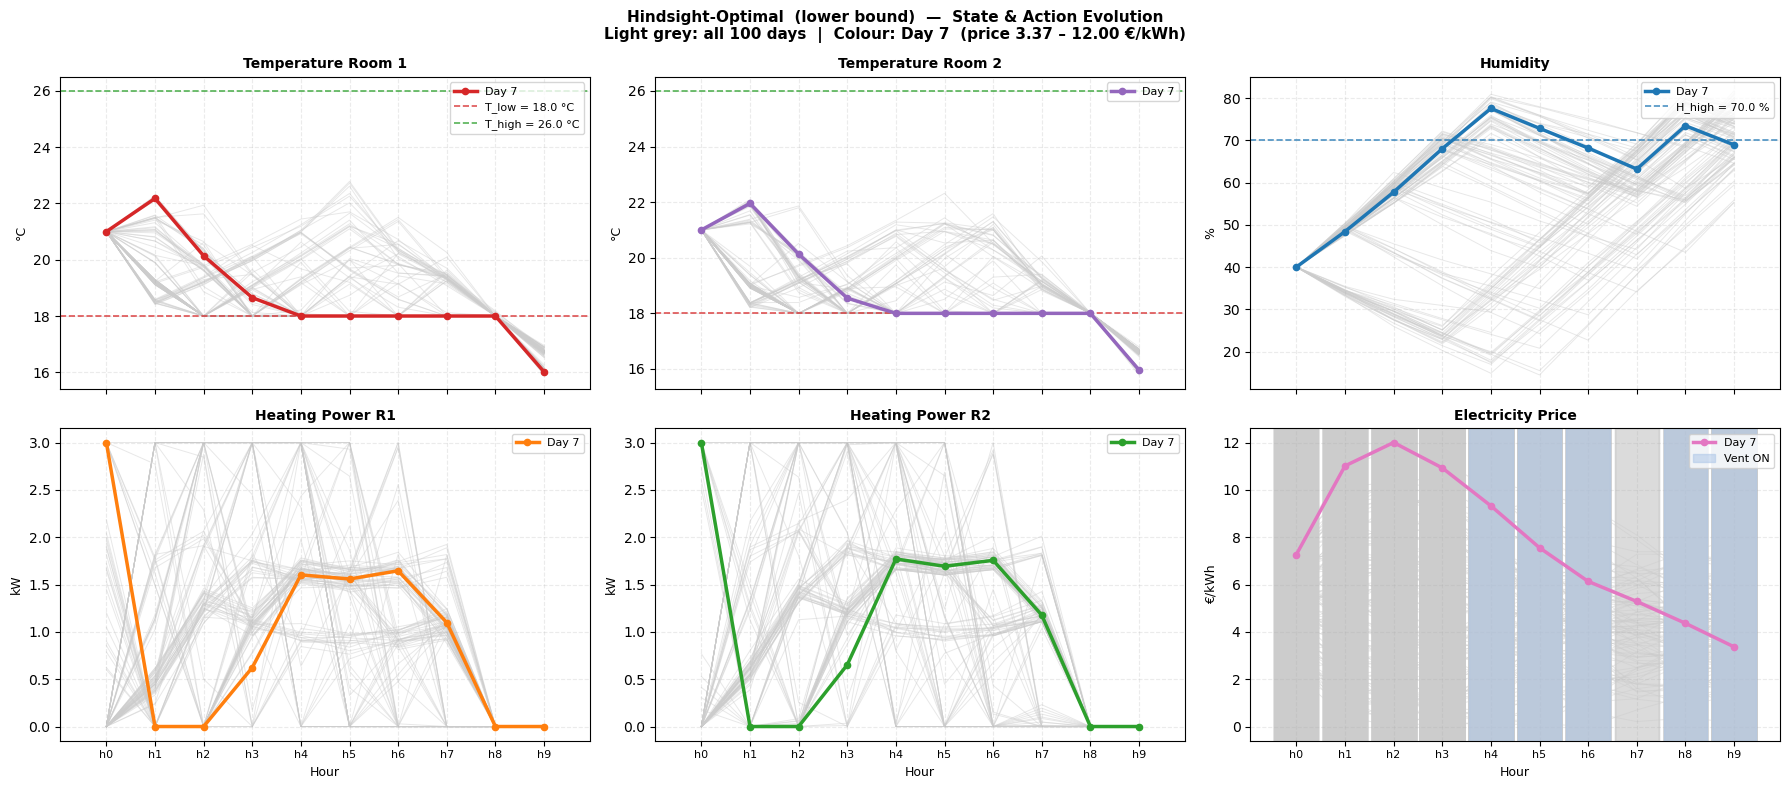

In [6]:
# Build hindsight trajectories directly from hindsight_details (no re-run needed).
# temperatures[t] = state at the START of step t (= what the policy would observe).
# actions[t]      = (p1, p2, v) chosen at step t.
_T1 = np.full((N_DAYS_PLOT, 10), np.nan)
_T2 = np.full((N_DAYS_PLOT, 10), np.nan)
_H  = np.full((N_DAYS_PLOT, 10), np.nan)
_p1 = np.zeros((N_DAYS_PLOT, 10)); _p2 = np.zeros((N_DAYS_PLOT, 10))
_v  = np.zeros((N_DAYS_PLOT, 10), dtype=int)

for _di, _det in enumerate(hindsight_details):
    if _det['feasible']:
        for _t in range(10):
            _T1[_di, _t], _T2[_di, _t], _H[_di, _t] = _det['temperatures'][_t]
            _p1[_di, _t], _p2[_di, _t], _v[_di, _t] = _det['actions'][_t]

ho_traj = {'T1': _T1, 'T2': _T2, 'H': _H,
           'p1': _p1, 'p2': _p2, 'v': _v,
           'price': PRICES_MAT}
plot_state_evolution(ho_traj, "Hindsight-Optimal  (lower bound)")

---
## 3. Dummy Policy Evaluation (reactive baseline)

The dummy policy takes **no optimisation decisions** it only reacts to mandatory overrule controllers:
- Heats at **P_max** only when `y_low_r = 1` (low-temperature overrule active).
- Ventilates only when `c > 0` (inertia counter) or `H >= H_high` (humidity overrule).

This is the **worst reasonable baseline**: any optimising policy should beat it.

In [7]:
n_days = len(pd.read_csv(price_csv))
print(f"Simulating Dummy policy on {n_days} days ...")
dummy_costs, dummy_times = run_policy(
    dummy_action, price_csv, occ1_csv, occ2_csv,
    policy_name="Dummy (reactive)",
    verbose=True,
)

print(f"\nDummy Policy Results:")
print(f"  Mean daily cost : {dummy_costs.mean():.3f} euro")
print(f"  Std             : {dummy_costs.std():.3f} euro")
print(f"  Min             : {dummy_costs.min():.3f} euro")
print(f"  Max             : {dummy_costs.max():.3f} euro")

Simulating Dummy policy on 100 days ...
  Day   1/100  |  cost =  192.53 euro  |  avg step = 0 ms
  Day   2/100  |  cost =  196.76 euro  |  avg step = 0 ms
  Day   3/100  |  cost =  256.84 euro  |  avg step = 0 ms
  Day   4/100  |  cost =  166.67 euro  |  avg step = 0 ms
  Day   5/100  |  cost =  223.49 euro  |  avg step = 0 ms
  Day   6/100  |  cost =   85.84 euro  |  avg step = 0 ms
  Day   7/100  |  cost =  320.51 euro  |  avg step = 0 ms
  Day   8/100  |  cost =  272.59 euro  |  avg step = 0 ms
  Day   9/100  |  cost =  145.85 euro  |  avg step = 0 ms
  Day  10/100  |  cost =  221.62 euro  |  avg step = 0 ms
  Day  11/100  |  cost =   37.37 euro  |  avg step = 0 ms
  Day  12/100  |  cost =  227.96 euro  |  avg step = 0 ms
  Day  13/100  |  cost =  259.94 euro  |  avg step = 0 ms
  Day  14/100  |  cost =  308.84 euro  |  avg step = 0 ms
  Day  15/100  |  cost =   72.25 euro  |  avg step = 0 ms
  Day  16/100  |  cost =  136.10 euro  |  avg step = 0 ms
  Day  17/100  |  cost =   24.58

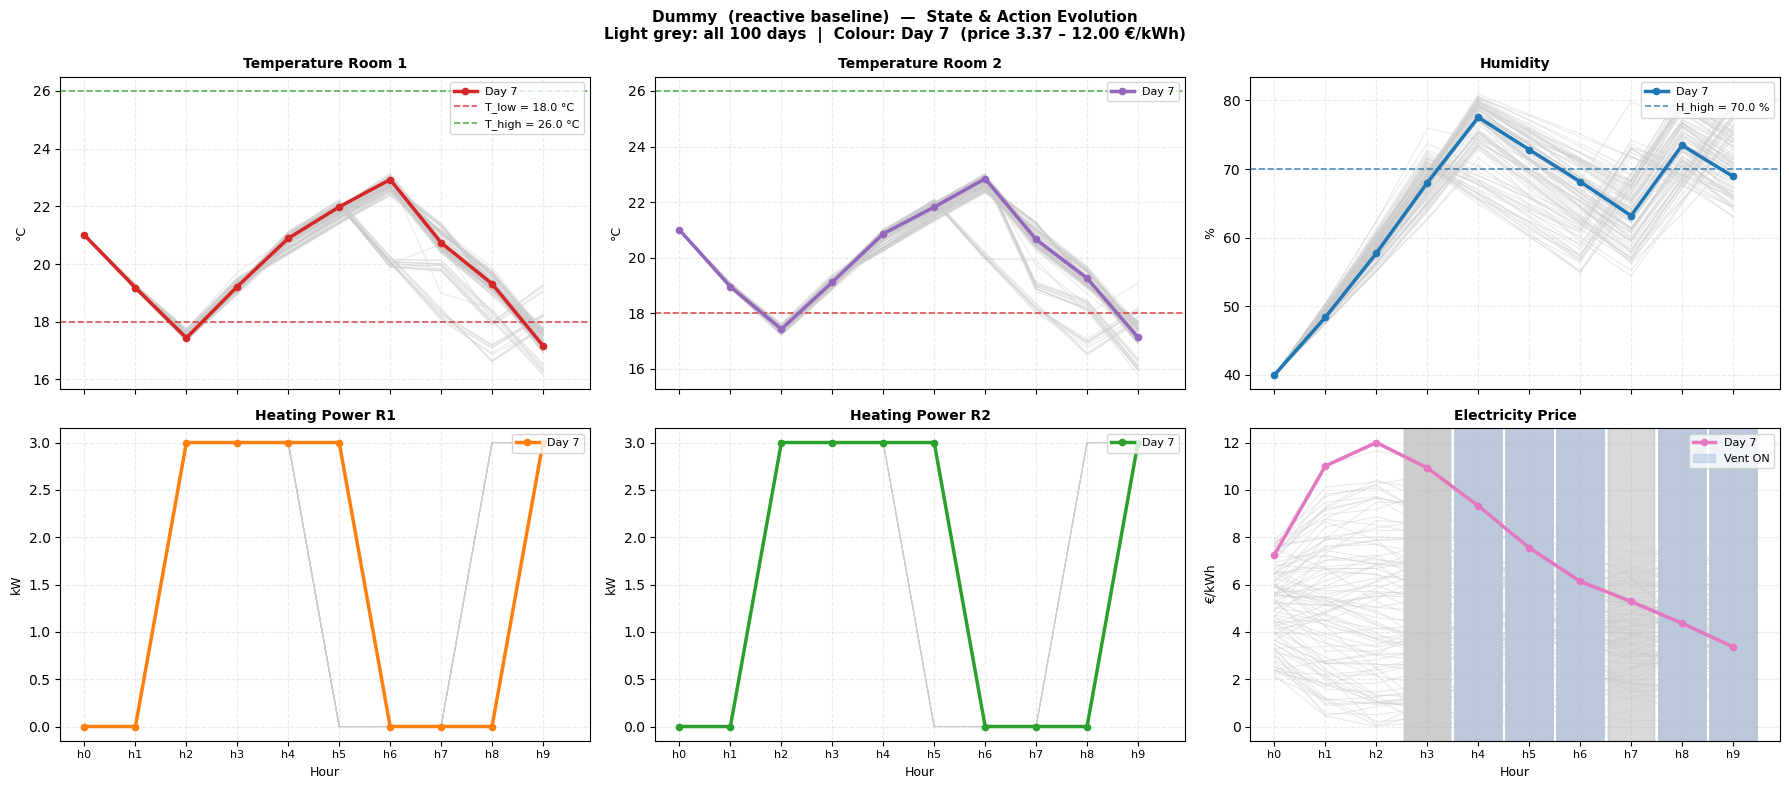

In [8]:
print("Collecting Dummy trajectories ...")
dummy_traj = collect_traj(dummy_action)
plot_state_evolution(dummy_traj, "Dummy  (reactive baseline)")

---
## 4. SP Policy Evaluation (horizon = 2, branches = 2)

Evaluates the SP policy on the **same 100 days from the CSV** above.  
At each hour the policy receives the current (realized) price and occupancy from the CSV,
builds a 2-stage scenario tree (branching = 2), solves the MILP, and returns the here-and-now action.  
Overrule controllers are applied by the simulator after the policy returns.

In [9]:
import importlib.util, sys

#  Load SP policy 
_sp_path = Path("SP_policy_14.py")
_spec    = importlib.util.spec_from_file_location("SP_policy_14", _sp_path)
_sp_mod  = importlib.util.module_from_spec(_spec)
sys.modules["SP_policy_14"] = _sp_mod
_spec.loader.exec_module(_sp_mod)
sp_select_action = _sp_mod.select_action   # horizon=2, branches=2, n_init=1000

print("SP policy loaded.")
n_days = len(pd.read_csv(price_csv))
print(f"\nSimulating SP policy on {n_days} days ...")

sp_costs, sp_times = run_policy(
    sp_select_action, price_csv, occ1_csv, occ2_csv,
    policy_name="SP (h=2, b=2)",
    verbose=True,
)

print(f"\nSP Policy Results (horizon=2, branches=2):")
print(f"  Mean daily cost : {sp_costs.mean():.3f} euro")
print(f"  Std             : {sp_costs.std():.3f} euro")
print(f"  Min             : {sp_costs.min():.3f} euro")
print(f"  Max             : {sp_costs.max():.3f} euro")

SP policy loaded.

Simulating SP policy on 100 days ...
  Day   1/100  |  cost =  162.41 euro  |  avg step = 65 ms
  Day   2/100  |  cost =  164.05 euro  |  avg step = 61 ms
  Day   3/100  |  cost =  193.19 euro  |  avg step = 69 ms
  Day   4/100  |  cost =  143.01 euro  |  avg step = 57 ms
  Day   5/100  |  cost =  181.28 euro  |  avg step = 66 ms
  Day   6/100  |  cost =   86.70 euro  |  avg step = 75 ms
  Day   7/100  |  cost =  237.78 euro  |  avg step = 77 ms
  Day   8/100  |  cost =  216.26 euro  |  avg step = 72 ms
  Day   9/100  |  cost =  120.83 euro  |  avg step = 71 ms
  Day  10/100  |  cost =  170.10 euro  |  avg step = 57 ms
  Day  11/100  |  cost =   44.40 euro  |  avg step = 57 ms
  Day  12/100  |  cost =  167.95 euro  |  avg step = 56 ms
  Day  13/100  |  cost =  201.97 euro  |  avg step = 71 ms
  Day  14/100  |  cost =  239.17 euro  |  avg step = 61 ms
  Day  15/100  |  cost =   65.73 euro  |  avg step = 51 ms
  Day  16/100  |  cost =  113.31 euro  |  avg step = 54 ms


c:\Users\ccano\anaconda3\envs\ieg_env2\Lib\site-packages\scipy\_lib\_util.py:365: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


  Day  47/100  |  cost =  143.66 euro  |  avg step = 64 ms
  Day  48/100  |  cost =  122.48 euro  |  avg step = 69 ms
  Day  49/100  |  cost =  166.51 euro  |  avg step = 96 ms
  Day  50/100  |  cost =  104.38 euro  |  avg step = 67 ms
  Day  51/100  |  cost =   48.43 euro  |  avg step = 65 ms
  Day  52/100  |  cost =   85.41 euro  |  avg step = 70 ms
  Day  53/100  |  cost =  154.57 euro  |  avg step = 57 ms
  Day  54/100  |  cost =  132.82 euro  |  avg step = 75 ms
  Day  55/100  |  cost =  105.67 euro  |  avg step = 88 ms
  Day  56/100  |  cost =   77.28 euro  |  avg step = 85 ms
  Day  57/100  |  cost =  224.20 euro  |  avg step = 113 ms
  Day  58/100  |  cost =  197.93 euro  |  avg step = 89 ms
  Day  59/100  |  cost =  172.23 euro  |  avg step = 75 ms
  Day  60/100  |  cost =  201.77 euro  |  avg step = 89 ms
  Day  61/100  |  cost =  196.31 euro  |  avg step = 82 ms
  Day  62/100  |  cost =   90.25 euro  |  avg step = 61 ms
  Day  63/100  |  cost =  141.59 euro  |  avg step = 66

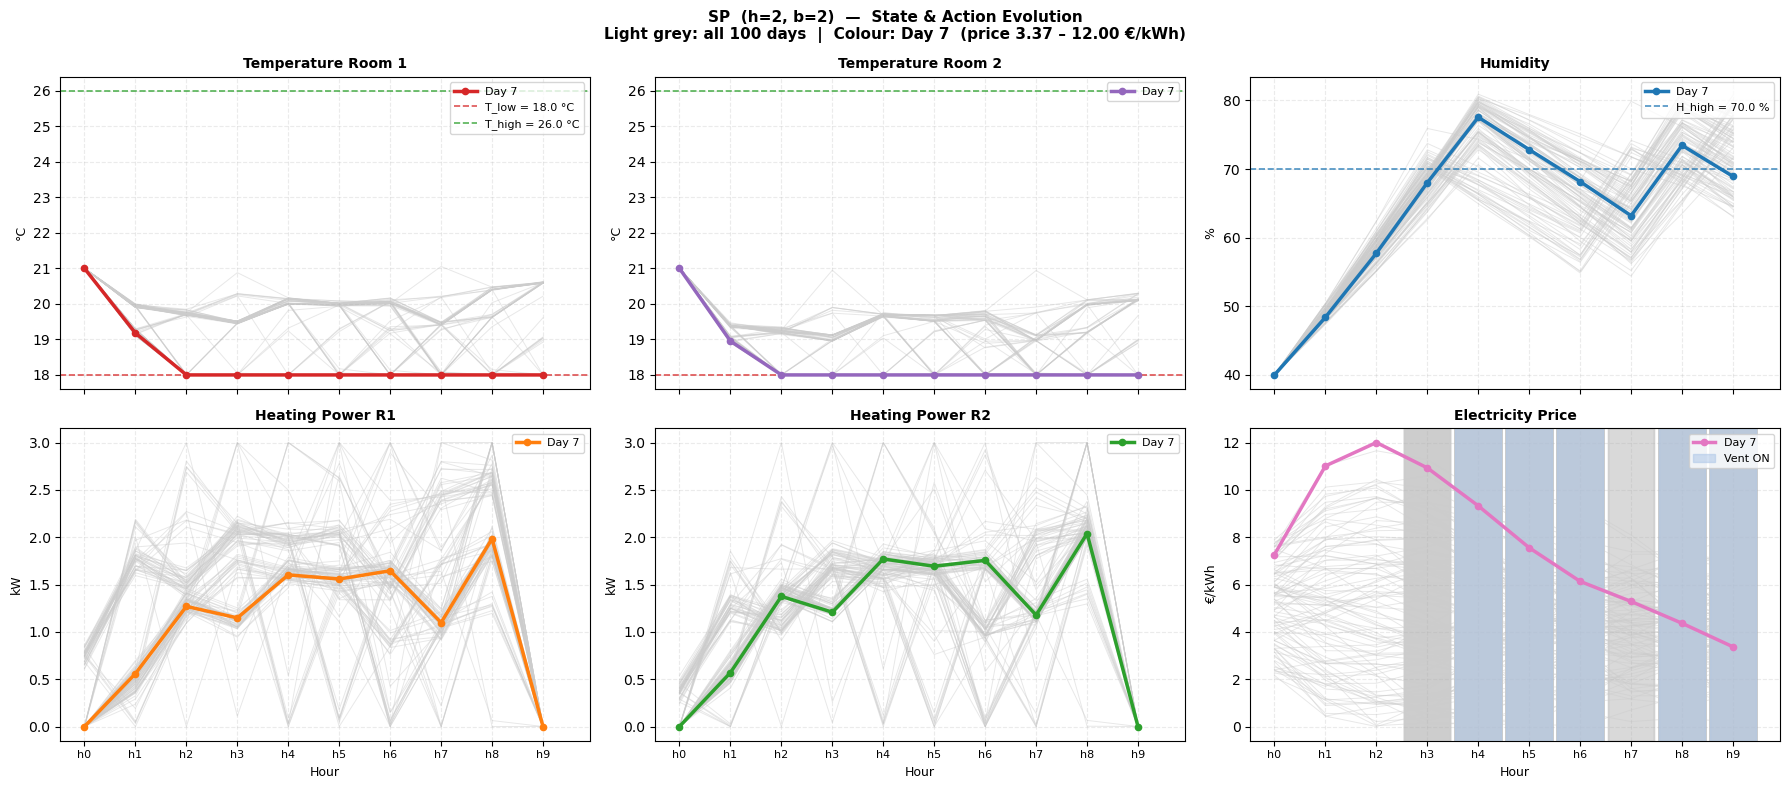

In [10]:
print("Collecting SP trajectories ...")
sp_traj = collect_traj(sp_select_action)
plot_state_evolution(sp_traj, "SP  (h=2, b=2)")

## 4. Two-stage Policy Evaluation (horizon = 1, branches = 10)

In [11]:
#  Load Two-stage policy 
_sp_path = Path("Two_stage_policy_14.py")
_spec    = importlib.util.spec_from_file_location("Two_stage_policy_14", _sp_path)
_sp_mod  = importlib.util.module_from_spec(_spec)
sys.modules["Two_stage_policy_14"] = _sp_mod
_spec.loader.exec_module(_sp_mod)
sp_select_action = _sp_mod.select_action   # horizon=1, branches=10, n_init=1000

print("SP policy loaded  (horizon=1, branches=10, n_init=1000).")
n_days = len(pd.read_csv(price_csv))
print(f"\nSimulating 2-stage policy on {n_days} days ...")

two_stage_costs, two_stage_times = run_policy(
    sp_select_action, price_csv, occ1_csv, occ2_csv,
    policy_name="2-stage (h=1, b=10)",
    verbose=True,
)

print(f"\n2-stage Policy Results (horizon=1, branches=10):")
print(f"  Mean daily cost : {two_stage_costs.mean():.3f} euro")
print(f"  Std             : {two_stage_costs.std():.3f} euro")
print(f"  Min             : {two_stage_costs.min():.3f} euro")
print(f"  Max             : {two_stage_costs.max():.3f} euro")

SP policy loaded  (horizon=1, branches=10, n_init=1000).

Simulating 2-stage policy on 100 days ...
  Day   1/100  |  cost =  179.65 euro  |  avg step = 60 ms
  Day   2/100  |  cost =  146.66 euro  |  avg step = 57 ms
  Day   3/100  |  cost =  193.19 euro  |  avg step = 116 ms
  Day   4/100  |  cost =  141.88 euro  |  avg step = 81 ms
  Day   5/100  |  cost =  166.78 euro  |  avg step = 64 ms
  Day   6/100  |  cost =   66.65 euro  |  avg step = 58 ms
  Day   7/100  |  cost =  247.88 euro  |  avg step = 67 ms
  Day   8/100  |  cost =  234.22 euro  |  avg step = 67 ms
  Day   9/100  |  cost =  112.62 euro  |  avg step = 72 ms
  Day  10/100  |  cost =  163.62 euro  |  avg step = 90 ms
  Day  11/100  |  cost =   35.31 euro  |  avg step = 67 ms
  Day  12/100  |  cost =  155.95 euro  |  avg step = 50 ms
  Day  13/100  |  cost =  202.37 euro  |  avg step = 62 ms
  Day  14/100  |  cost =  258.48 euro  |  avg step = 62 ms
  Day  15/100  |  cost =   48.76 euro  |  avg step = 63 ms
model.name="un

c:\Users\ccano\anaconda3\envs\ieg_env2\Lib\site-packages\scipy\_lib\_util.py:365: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
  Day  53/100  |  cost =  210.33 euro  |  avg step = 52 ms
  Day  54/100  |  cost =  119.10 euro  |  avg step = 54 ms
  Day  55/100  |  cost =  120.58 euro  |  avg step = 51 ms
  Day  56/100  |  cost =   57.79 euro  |  avg step = 61 ms
  Day  57/100  |  cost =  234.67 euro  |  avg step = 53 ms
  Day  58/100  |  cost =  197.93 euro  |  avg step = 66 ms
  Day  59/100  |  cost =  172.23 euro  |  avg step = 61 ms
  Day  60/100  |  cost =  204.30 euro  |  avg step = 105 ms
  Day  61/100  |  cost =  213.65 euro  |  avg step = 70 ms
  Day  62/100  |  cost =   85.82 euro  |  avg step = 85 ms
  Day  63/100  |  cost =  156.06 euro

model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
model.na

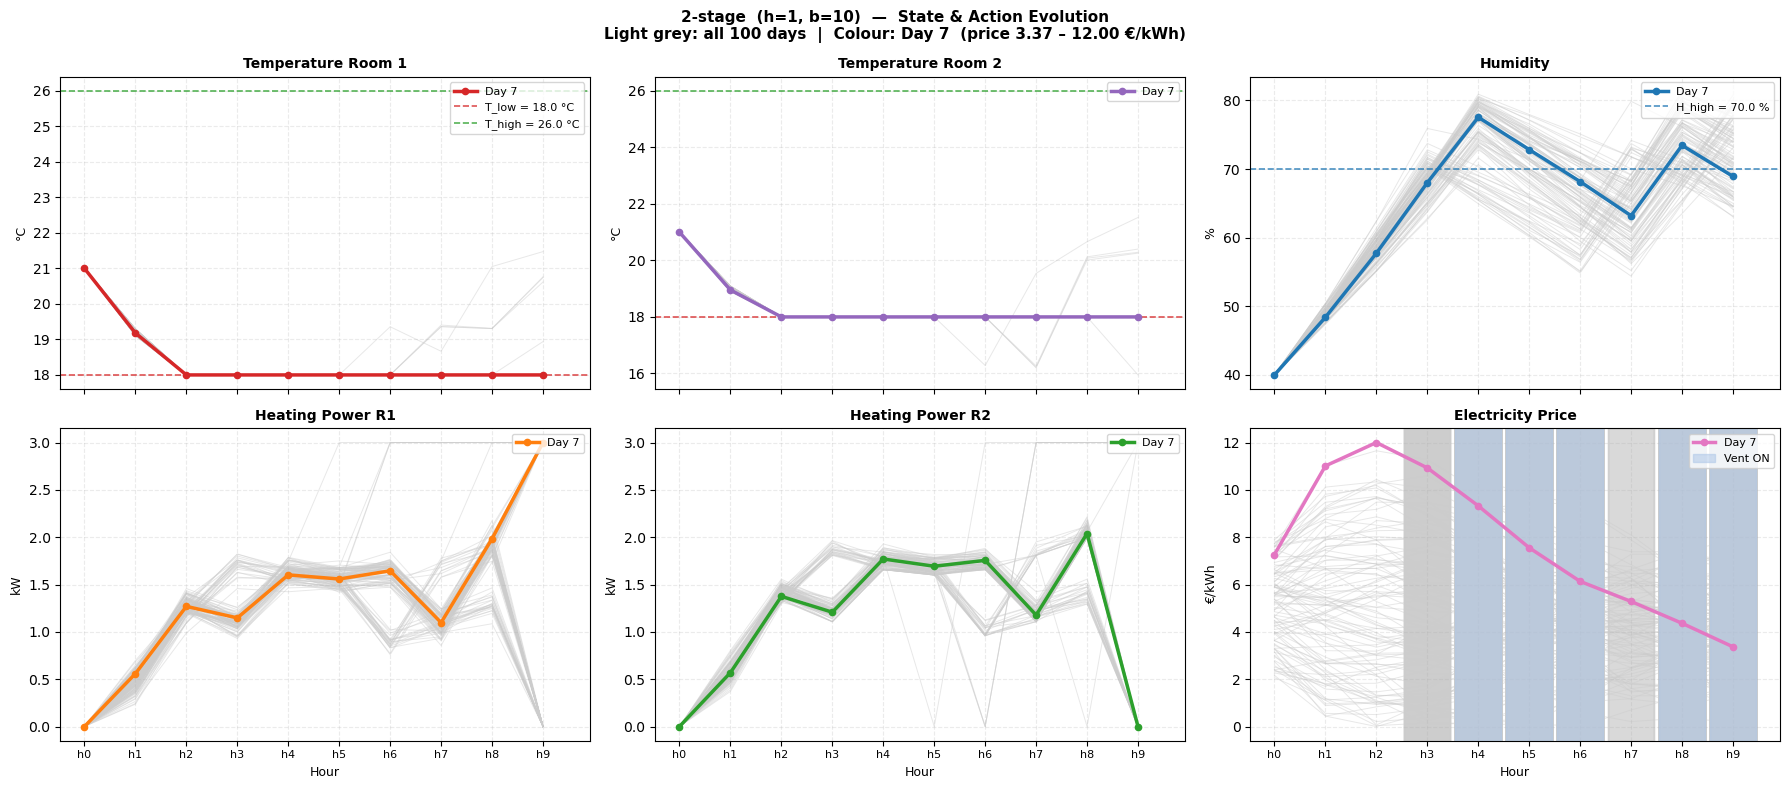

In [12]:
print("Collecting 2-stage trajectories ...")
two_stage_traj = collect_traj(sp_select_action)   # sp_select_action now points to 2-stage
plot_state_evolution(two_stage_traj, "2-stage  (h=1, b=10)")

---
## 5. API Policy Evaluation (time-indexed Ridge VFA, trained by ADP_Training_NEW.py)

Evaluates the Approximate Policy Iteration policy.  
At each hour **t** the policy solves a single-step MILP with a **K=15 Monte-Carlo
look-ahead** using the time-indexed VFA weights `vfa_weights[t+1]` loaded from
`api_vfa_weights.json`.

**Prerequisite:** run `ADP_Training_NEW.py` first to produce `api_vfa_weights.json`.

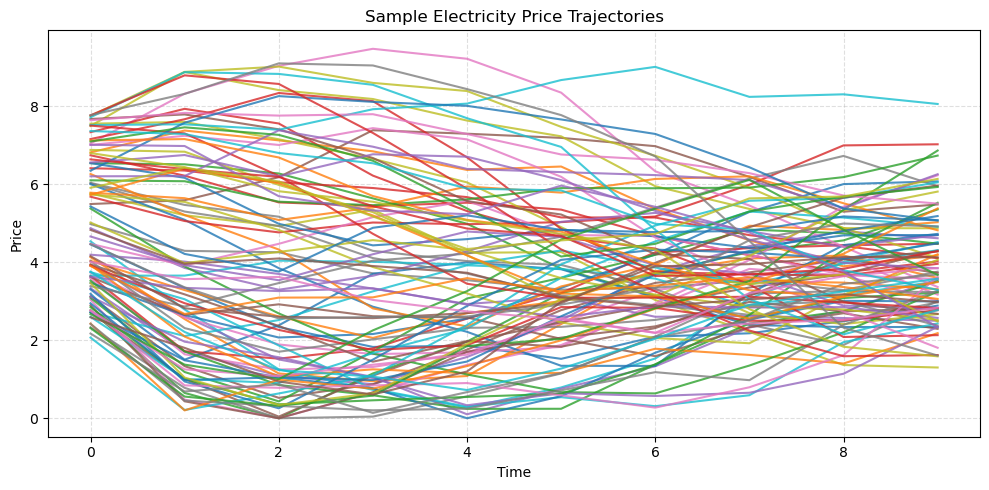

API policy loaded  (time-indexed Ridge VFA, 10 features × 10 time steps).

Simulating API policy on 100 days ...
  Day   1/100  |  cost =  185.46 euro  |  avg step = 26 ms
  Day   2/100  |  cost =  196.76 euro  |  avg step = 27 ms
  Day   3/100  |  cost =  256.84 euro  |  avg step = 39 ms
  Day   4/100  |  cost =  169.32 euro  |  avg step = 42 ms
  Day   5/100  |  cost =  223.49 euro  |  avg step = 43 ms
  Day   6/100  |  cost =   62.32 euro  |  avg step = 39 ms
  Day   7/100  |  cost =  320.51 euro  |  avg step = 38 ms
  Day   8/100  |  cost =  272.59 euro  |  avg step = 32 ms
  Day   9/100  |  cost =  143.27 euro  |  avg step = 36 ms
  Day  10/100  |  cost =  221.62 euro  |  avg step = 34 ms
  Day  11/100  |  cost =   55.96 euro  |  avg step = 34 ms
  Day  12/100  |  cost =  233.17 euro  |  avg step = 37 ms
  Day  13/100  |  cost =  259.94 euro  |  avg step = 42 ms
  Day  14/100  |  cost =  308.84 euro  |  avg step = 40 ms
  Day  15/100  |  cost =   47.48 euro  |  avg step = 38 ms
  

In [13]:
# Load API policy (requires api_vfa_weights.json produced by ADP_Training_NEW.py)
_api_spec = importlib.util.spec_from_file_location("API_policy_14", Path("API_policy_14.py"))
_api_mod  = importlib.util.module_from_spec(_api_spec)
sys.modules["API_policy_14"] = _api_mod
_api_spec.loader.exec_module(_api_mod)
api_select_action = _api_mod.select_action

print("API policy loaded  (time-indexed Ridge VFA, 10 features × 10 time steps).")

n_days = len(pd.read_csv(price_csv))
print(f"\nSimulating API policy on {n_days} days ...")
api_costs, api_times = run_policy(
    api_select_action, price_csv, occ1_csv, occ2_csv,
    policy_name="API (Ridge VFA)",
    verbose=True,
)

print(f"\nAPI Policy Results:")
print(f"  Mean daily cost : {api_costs.mean():.3f} euro")
print(f"  Std             : {api_costs.std():.3f} euro")
print(f"  Min             : {api_costs.min():.3f} euro")
print(f"  Max             : {api_costs.max():.3f} euro")

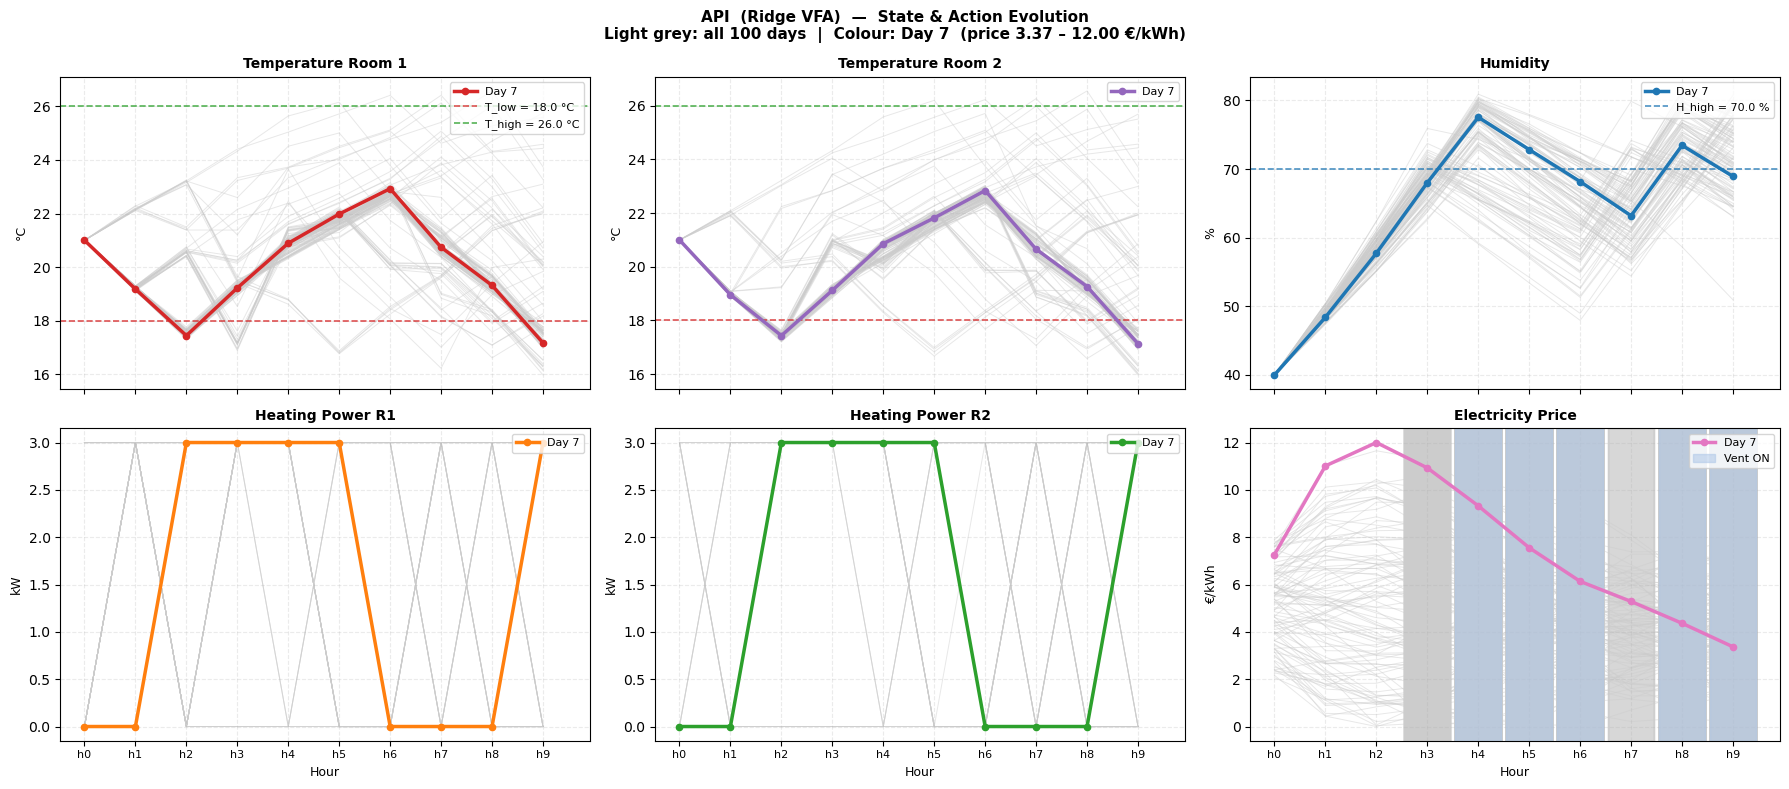

In [14]:
print("Collecting API trajectories ...")
api_traj = collect_traj(api_select_action)
plot_state_evolution(api_traj, "API  (Ridge VFA)")

In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import to_hex
import numpy as np

# ── Collect all results ───────────────────────────────────────────────────────
_all = {
    "Hindsight-Optimal\n(lower bound)": hindsight_costs,
    "SP\n(h=2, b=2)"                  : sp_costs,
    "API\n(Ridge VFA)"                : api_costs,
    "2-stage (h=1, b=10)"             : two_stage_costs,
    "Dummy\n(reactive)"               : dummy_costs,
}
_colors = {
    "Hindsight-Optimal\n(lower bound)": "#55A868",
    "SP\n(h=2, b=2)"                  : "#4C72B0",
    "API\n(Ridge VFA)"                : "#9467BD",
    "2-stage (h=1, b=10)"             : "#8C564B",
    "Dummy\n(reactive)"               : "#C44E52",
}

valid_h = hindsight_costs[~np.isnan(hindsight_costs)]

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for name, arr in _all.items():
    v = arr[~np.isnan(arr)]
    gap = (v.mean() - valid_h.mean()) / valid_h.mean() * 100
    rows.append({
        "Policy":              name.replace("\n", " "),
        "Mean (euro)":         round(v.mean(), 2),
        "Std (euro)":          round(v.std(),  2),
        "Min (euro)":          round(v.min(),  2),
        "Max (euro)":          round(v.max(),  2),
        "Gap to Optimal (%)":  round(gap, 1),
    })

summary_df = pd.DataFrame(rows).sort_values("Mean (euro)").reset_index(drop=True)

hindsight_mean = valid_h.mean()
dummy_mean = dummy_costs[~np.isnan(dummy_costs)].mean()
dummy_gap = (dummy_mean - hindsight_mean) / hindsight_mean * 100

def color_gap(val):
    if val > dummy_gap:
        return "background-color: #8B0000"
    ratio = np.clip(val / dummy_gap if dummy_gap > 0 else 0, 0, 1)
    r = 0.0 + ratio * 0.7
    g = 0.5 + ratio * 0.1
    b = 0.1 - ratio * 0.1
    return f"background-color: {to_hex((r, g, b))}"

display(summary_df.style
    .map(color_gap, subset=['Gap to Optimal (%)'])
    .format({"Mean (euro)": "{:.2f}", "Std (euro)": "{:.2f}",
             "Min (euro)":  "{:.2f}", "Max (euro)": "{:.2f}",
             "Gap to Optimal (%)": "{:.1f}"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color","#3949AB"),("color","white"),
                                     ("font-size","13px"),("text-align","left")]},
        {"selector": "td", "props": [("font-size","12px"),("padding","5px 12px")]},
    ])
    .hide(axis="index")
)

Policy,Mean (euro),Std (euro),Min (euro),Max (euro),Gap to Optimal (%)
Hindsight-Optimal (lower bound),117.71,58.36,5.78,248.25,0.0
"SP (h=2, b=2)",150.94,54.78,23.47,286.15,28.2
"2-stage (h=1, b=10)",152.80,60.39,22.49,286.39,29.8
Dummy (reactive),183.05,76.68,24.58,368.23,55.5
API (Ridge VFA),184.56,76.69,35.91,368.23,56.8


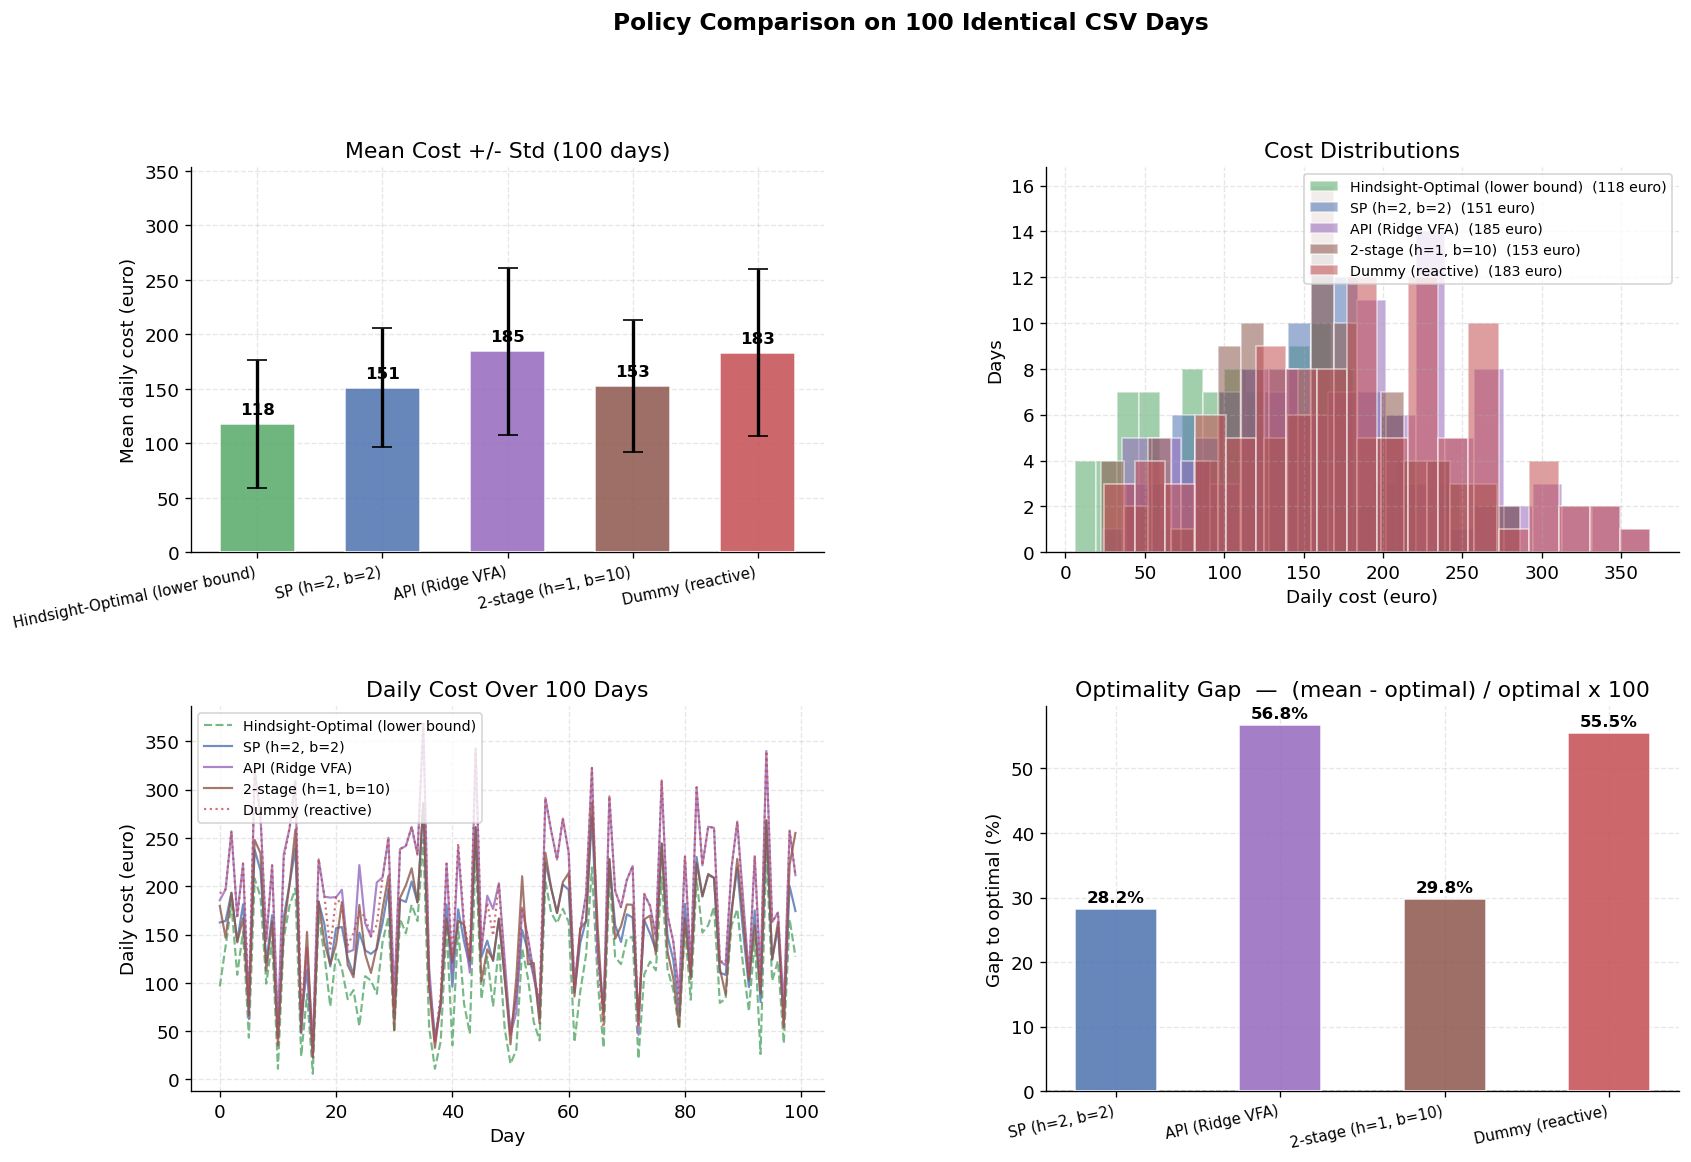

Saved -> output\all_policies_comparison.png


In [16]:
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--"})

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

names  = list(_all.keys())
arrays = list(_all.values())
cols   = [_colors[n] for n in names]
days   = np.arange(len(sp_costs))

# ── Top-left: mean +/- std bar chart ─────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
x = np.arange(len(names))
means = [arr[~np.isnan(arr)].mean() for arr in arrays]
stds  = [arr[~np.isnan(arr)].std()  for arr in arrays]
bars  = ax.bar(x, means, yerr=stds, capsize=6, color=cols,
               alpha=0.85, edgecolor="white", width=0.6, zorder=3,
               error_kw={"elinewidth": 2, "ecolor": "black"})
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds)*0.08,
            f"{val:.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([n.replace("\n", " ") for n in names], rotation=12, ha="right", fontsize=9)
ax.set_ylabel("Mean daily cost (euro)")
ax.set_title("Mean Cost +/- Std (100 days)")
ax.set_ylim(0, max(means) + max(stds) * 2.2)

# ── Top-right: overlapping distributions ─────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
for name, arr, col in zip(names, arrays, cols):
    v = arr[~np.isnan(arr)]
    ax.hist(v, bins=18, alpha=0.55, color=col, edgecolor="white",
            label=f"{name.replace(chr(10),' ')}  ({v.mean():.0f} euro)")
ax.set_xlabel("Daily cost (euro)")
ax.set_ylabel("Days")
ax.set_title("Cost Distributions")
ax.legend(fontsize=8.5)

# ── Bottom-left: per-day timeline ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ls_map = {
    "Hindsight-Optimal\n(lower bound)": "--",
    "SP\n(h=2, b=2)"  : "-",
    "ADP\n(11-feat VFA)": "-",
    "Hybrid\n(SP+ADP)": "-.",
    "Dummy\n(reactive)": ":",
}
for name, arr, col in zip(names, arrays, cols):
    ax.plot(days, arr, color=col, lw=1.3, alpha=0.8,
            linestyle=ls_map.get(name, "-"),
            label=name.replace("\n", " "))
ax.set_xlabel("Day")
ax.set_ylabel("Daily cost (euro)")
ax.set_title("Daily Cost Over 100 Days")
ax.legend(fontsize=8.5)

# ── Bottom-right: gap to optimal ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
gap_names  = [n for n in names if "Hindsight" not in n]
gap_values = [(arrays[names.index(n)][~np.isnan(arrays[names.index(n)])].mean()
               - valid_h.mean()) / valid_h.mean() * 100
              for n in gap_names]
gap_colors = [_colors[n] for n in gap_names]
x2 = np.arange(len(gap_names))
gbars = ax.bar(x2, gap_values, color=gap_colors, alpha=0.85,
               edgecolor="white", width=0.5, zorder=3)
for bar, val in zip(gbars, gap_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(x2)
ax.set_xticklabels([n.replace("\n", " ") for n in gap_names], rotation=12, ha="right", fontsize=9)
ax.set_ylabel("Gap to optimal (%)")
ax.set_title("Optimality Gap  —  (mean - optimal) / optimal x 100")
ax.axhline(0, color="black", lw=0.8, ls="--")

plt.suptitle("Policy Comparison on 100 Identical CSV Days",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(INPUT_OUTPUT_DIR / "all_policies_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {INPUT_OUTPUT_DIR / 'all_policies_comparison.png'}")